# Fisher-Rao energy geometry — Laguerre cells

Self-contained (no trained checkpoint needed).

**Laguerre cells** = regions of ℝ² where each training atom dominates the posterior `w̃ᵢ(z)`.  
For equal-weight, equal-variance Gaussian mixtures these are standard Voronoi cells of the scaled atom positions `√ᾱ_t xᵢ`.

**Fisher-Rao energy** `I(y) = Var_{w̃} / σ_t⁴` is overlaid:
- **Dark** (low `I`) = centre of a cell = one atom dominates = memorised
- **Bright** (high `I`) = cell boundary = posterior split across atoms = diverse

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── Config ────────────────────────────────────────────────────────────────────
N_ATOMS  = 12
U_RANGE  = 3.2
SEED     = 7
BETA_MIN = 0.1
BETA_MAX = 20.0
T_PANELS = [0.05, 0.15, 0.35, 0.70]
GRID_NX  = 400
GRID_NY  = 280

torch.manual_seed(SEED)

def manifold_from_u(u):
    return torch.stack([u, 0.6 * torch.sin(2 * u)], dim=-1)

u_atoms = (torch.rand(N_ATOMS) * 2 - 1) * U_RANGE
X_atoms = manifold_from_u(u_atoms)           # [N, 2]
u_curve = torch.linspace(-U_RANGE * 1.05, U_RANGE * 1.05, 800)
curve   = manifold_from_u(u_curve)

def alpha_bar(t):
    t = torch.as_tensor(t, dtype=torch.float32)
    return torch.exp(-(BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2))

def sigma2(t):
    return (1.0 - alpha_bar(t)).clamp(min=1e-6)


def compute_grid(t_val, nx=GRID_NX, ny=GRID_NY,
                 xlim=(-4.2, 4.2), ylim=(-2.5, 2.5)):
    """Returns gx, gy, GX, GY, energy [ny,nx], assignment [ny,nx] (int)."""
    ab  = alpha_bar(t_val).item()
    s2  = sigma2(t_val).item()
    gx  = np.linspace(*xlim, nx)
    gy  = np.linspace(*ylim, ny)
    GX, GY = np.meshgrid(gx, gy)
    pts  = torch.tensor(np.stack([GX, GY], -1).reshape(-1, 2), dtype=torch.float32)
    mu   = X_atoms * ab ** 0.5            # scaled atom positions [N, 2]
    diff = pts[:, None, :] - mu[None, :, :]   # [M, N, 2]
    sq_d = (diff ** 2).sum(-1)                 # [M, N]
    # Posterior weights via softmax of -||z - µᵢ||² / 2σ²
    lw   = -sq_d / (2 * s2)
    lw  -= lw.max(1, keepdim=True).values
    w    = lw.exp();  w /= w.sum(1, keepdim=True)
    # Posterior variance = Σᵢ w̃ᵢ ||µᵢ - µ̄||²
    mbar = (w[:, :, None] * mu[None]).sum(1)   # [M, 2]
    delt = mu[None] - mbar[:, None]             # [M, N, 2]
    var  = (w * (delt**2).sum(-1)).sum(1)        # [M]
    energy     = (var / s2**2).reshape(ny, nx).numpy()
    assignment = w.argmax(1).reshape(ny, nx).numpy()
    return gx, gy, GX, GY, energy, assignment, ab, s2

print(f'Atoms: {X_atoms.shape}, grid: {GRID_NX}×{GRID_NY}')

Atoms: torch.Size([12, 2]), grid: 400×280


Saved → fisher_rao_geometry.png


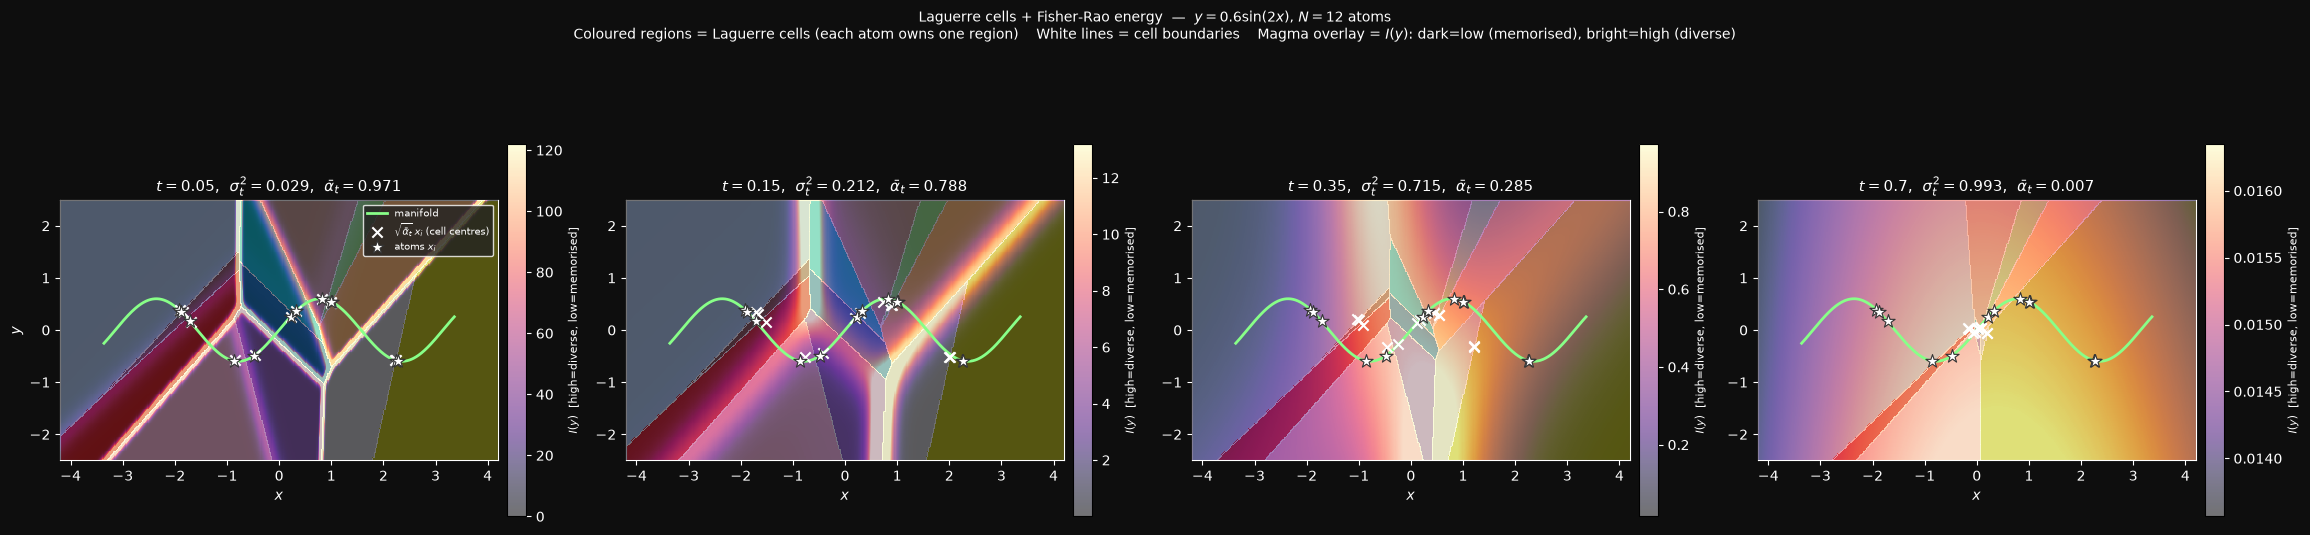

In [9]:
# ── Pick a distinct colour per atom ──────────────────────────────────────────
# Use a qualitative palette so adjacent cells are easy to distinguish
qual_colors = [plt.colormaps['tab20'](i / N_ATOMS) for i in range(N_ATOMS)]
cell_cmap   = ListedColormap(qual_colors)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(T_PANELS), figsize=(5.8 * len(T_PANELS), 5.8),
                         facecolor='#0e0e0e')

for ax, t_val in zip(axes, T_PANELS):
    ax.set_facecolor('#0e0e0e')
    gx, gy, GX, GY, energy, assignment, ab, s2 = compute_grid(t_val)
    mu_np = (X_atoms * ab**0.5).numpy()   # scaled atom positions at this t

    # 1. Laguerre cell fill — solid colours, one per atom
    ax.pcolormesh(GX, GY, assignment,
                  cmap=cell_cmap, vmin=0, vmax=N_ATOMS - 1,
                  alpha=1.0, shading='auto', zorder=0)

    # 2. Cell boundaries — detect where argmax flips between neighbours
    h_edge = (assignment[:-1, :] != assignment[1:, :])   # horizontal edges
    v_edge = (assignment[:, :-1] != assignment[:, 1:])   # vertical edges
    hy, hx = np.where(h_edge)
    vy, vx = np.where(v_edge)
    if len(hy):
        ax.scatter(gx[hx], (gy[hy] + gy[hy+1]) / 2,
                   s=0.5, color='white', linewidths=0, zorder=2, alpha=0.9)
    if len(vy):
        ax.scatter((gx[vx] + gx[vx+1]) / 2, gy[vy],
                   s=0.5, color='white', linewidths=0, zorder=2, alpha=0.9)

    # 3. Fisher-Rao energy overlay (magma, semi-transparent on top of cells)
    e_plot = np.clip(energy, 0, np.percentile(energy, 96))
    im = ax.pcolormesh(GX, GY, e_plot,
                       cmap='magma', alpha=0.55, shading='auto', zorder=3)
    cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cb.set_label(r'$I(y)$  [high=diverse, low=memorised]', color='white', fontsize=8)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

    # 4. Manifold curve
    ax.plot(curve[:, 0].numpy(), curve[:, 1].numpy(),
            color='#88ff88', lw=2.0, zorder=5, label='manifold')

    # 5. Scaled atom positions µᵢ = √ᾱ_t xᵢ  (Laguerre cell centres)
    ax.scatter(mu_np[:, 0], mu_np[:, 1],
               s=55, marker='x', color='white', linewidths=1.5,
               zorder=6, label=r'$\sqrt{\bar{\alpha}_t}\,x_i$ (cell centres)')

    # 6. Original atom positions
    ax.scatter(X_atoms[:, 0].numpy(), X_atoms[:, 1].numpy(),
               s=100, marker='*', color='white',
               edgecolors='#333333', linewidths=0.8, zorder=7, label='atoms $x_i$')

    ax.set_xlim(gx[0], gx[-1])
    ax.set_ylim(gy[0], gy[-1])
    ax.set_aspect('equal')
    ax.set_title(
        f'$t = {t_val}$,  $\\sigma_t^2 = {s2:.3f}$,  $\\bar{{\\alpha}}_t = {ab:.3f}$',
        fontsize=11, color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.set_xlabel('$x$', color='white')
    if ax is axes[0]:
        ax.set_ylabel('$y$', color='white')
        ax.legend(fontsize=7, loc='upper right',
                  facecolor='#222', edgecolor='white', labelcolor='white')

fig.suptitle(
    f'Laguerre cells + Fisher-Rao energy  —  $y=0.6\\sin(2x)$, $N={N_ATOMS}$ atoms\n'
    'Coloured regions = Laguerre cells (each atom owns one region)    '
    'White lines = cell boundaries    '
    r'Magma overlay = $I(y)$: dark=low (memorised), bright=high (diverse)',
    fontsize=10, color='white', y=1.01)

plt.tight_layout()
plt.savefig('fisher_rao_geometry.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print('Saved → fisher_rao_geometry.png')
plt.show()

Saved → fisher_rao_1d_slice.png


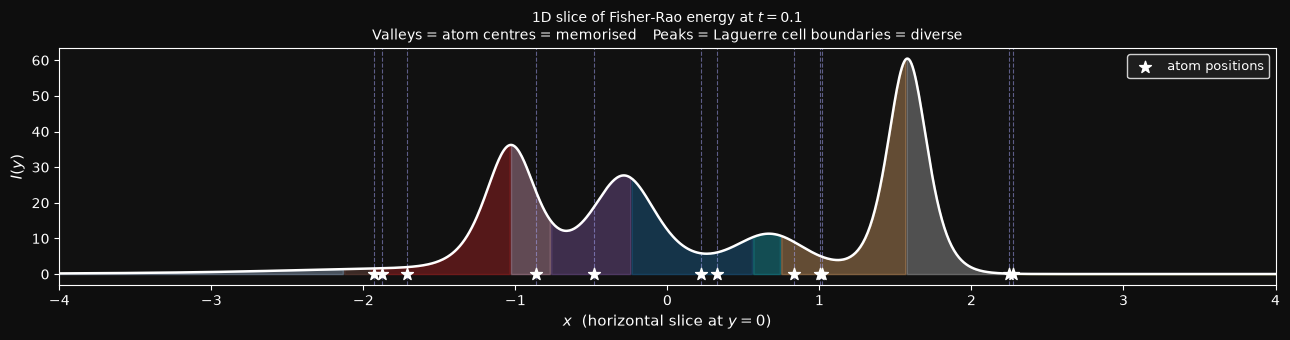

In [10]:
# ── 1D slice: valley-peak structure ─────────────────────────────────────────
T_SLICE = 0.1
ab_s = alpha_bar(T_SLICE).item()
s2_s = sigma2(T_SLICE).item()
mu_s = X_atoms * ab_s ** 0.5

x_vals  = torch.linspace(-4.0, 4.0, 1000)
z_slice = torch.stack([x_vals, torch.zeros_like(x_vals)], dim=-1)
diff_s  = z_slice[:, None, :] - mu_s[None, :, :]
sq_d_s  = (diff_s ** 2).sum(-1)
lw_s    = -sq_d_s / (2 * s2_s)
lw_s   -= lw_s.max(1, keepdim=True).values
w_s     = lw_s.exp();  w_s /= w_s.sum(1, keepdim=True)
mbar_s  = (w_s[:, :, None] * mu_s[None]).sum(1)
delt_s  = mu_s[None] - mbar_s[:, None]
var_s   = (w_s * (delt_s**2).sum(-1)).sum(1)
I_slice = (var_s / s2_s**2).numpy()

fig, ax = plt.subplots(figsize=(13, 3.5), facecolor='#0e0e0e')
ax.set_facecolor('#111')

# shade each Laguerre cell
x_np = x_vals.numpy()
for i in range(N_ATOMS):
    # compute argmax along the 1D slice to find cell ownership
    owner = w_s.argmax(1).numpy()
    mask  = (owner == i)
    if mask.any():
        ax.fill_between(x_np, 0, I_slice,
                        where=mask, color=qual_colors[i], alpha=0.35, zorder=1)

ax.plot(x_np, I_slice, color='white', lw=1.8, zorder=3)

for xi in X_atoms[:, 0].numpy():
    ax.axvline(xi, color='#aaaaff', lw=0.8, alpha=0.5, ls='--', zorder=2)
ax.scatter(X_atoms[:, 0].numpy(), np.zeros(N_ATOMS),
           s=80, marker='*', color='white', zorder=5, label='atom positions')

ax.set_xlabel('$x$  (horizontal slice at $y = 0$)', color='white', fontsize=11)
ax.set_ylabel(r'$I(y)$', color='white', fontsize=11)
ax.set_title(
    f'1D slice of Fisher-Rao energy at $t={T_SLICE}$\n'
    'Valleys = atom centres = memorised    Peaks = Laguerre cell boundaries = diverse',
    fontsize=10, color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('white')
ax.legend(fontsize=9, facecolor='#222', edgecolor='white', labelcolor='white')
ax.set_xlim(-4, 4)
plt.tight_layout()
plt.savefig('fisher_rao_1d_slice.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print('Saved → fisher_rao_1d_slice.png')
plt.show()

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# Circle manifold — cleaner intuition figure for the paper
# ═══════════════════════════════════════════════════════════════════════════════
#
# Atoms are placed uniformly on a circle of radius R.
# Laguerre cells become "pizza slices" — immediately readable.
# The collapse at large t is dramatic: the whole ring shrinks to a point.

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

CIRCLE_R   = 1.8     # radius of the manifold
N_CIRCLE   = 10      # number of training atoms (uniform spacing)
T_CIRCLE   = [0.005, 0.05, 0.15, 0.35, 0.70]
GRID_NX_C  = 400
GRID_NY_C  = 400
BETA_MIN_C = 0.1
BETA_MAX_C = 20.0

def alpha_bar_c(t):
    t = torch.as_tensor(t, dtype=torch.float32)
    return torch.exp(-(BETA_MIN_C * t + 0.5 * (BETA_MAX_C - BETA_MIN_C) * t ** 2))

def sigma2_c(t):
    return (1.0 - alpha_bar_c(t)).clamp(min=1e-6)

# Uniform atom placement on the circle
# Random spacing — some atoms close together, some far apart
torch.manual_seed(42)
theta_atoms = torch.sort(torch.rand(N_CIRCLE) * 2 * torch.pi).values
# Add a deliberate cluster: push two atoms close together
theta_atoms[3] = theta_atoms[2] + 0.18   # tight cluster
theta_atoms[7] = theta_atoms[6] + 0.22   # another cluster
X_circle    = torch.stack([CIRCLE_R * theta_atoms.cos(),
                            CIRCLE_R * theta_atoms.sin()], dim=-1)   # [N, 2]

# Dense circle for plotting
theta_curve = torch.linspace(0, 2 * torch.pi, 500)
curve_c     = torch.stack([CIRCLE_R * theta_curve.cos(),
                            CIRCLE_R * theta_curve.sin()], dim=-1)

def compute_grid_circle(t_val, nx=GRID_NX_C, ny=GRID_NY_C,
                         lim=(-3.2, 3.2)):
    ab  = alpha_bar_c(t_val).item()
    s2  = sigma2_c(t_val).item()
    gx  = np.linspace(*lim, nx)
    gy  = np.linspace(*lim, ny)
    GX, GY = np.meshgrid(gx, gy)
    pts  = torch.tensor(np.stack([GX, GY], -1).reshape(-1, 2), dtype=torch.float32)
    mu   = X_circle * ab ** 0.5
    diff = pts[:, None, :] - mu[None, :, :]
    sq_d = (diff ** 2).sum(-1)
    lw   = -sq_d / (2 * s2)
    lw  -= lw.max(1, keepdim=True).values
    w    = lw.exp();  w /= w.sum(1, keepdim=True)
    mbar = (w[:, :, None] * mu[None]).sum(1)
    delt = mu[None] - mbar[:, None]
    var  = (w * (delt**2).sum(-1)).sum(1)
    energy     = (var / s2**2).reshape(ny, nx).numpy()
    assignment = w.argmax(1).reshape(ny, nx).numpy()
    return gx, gy, GX, GY, energy, assignment, ab, s2

print(f"Circle atoms: {X_circle.shape}")


Circle atoms: torch.Size([10, 2])


Saved → fisher_rao_circle.png


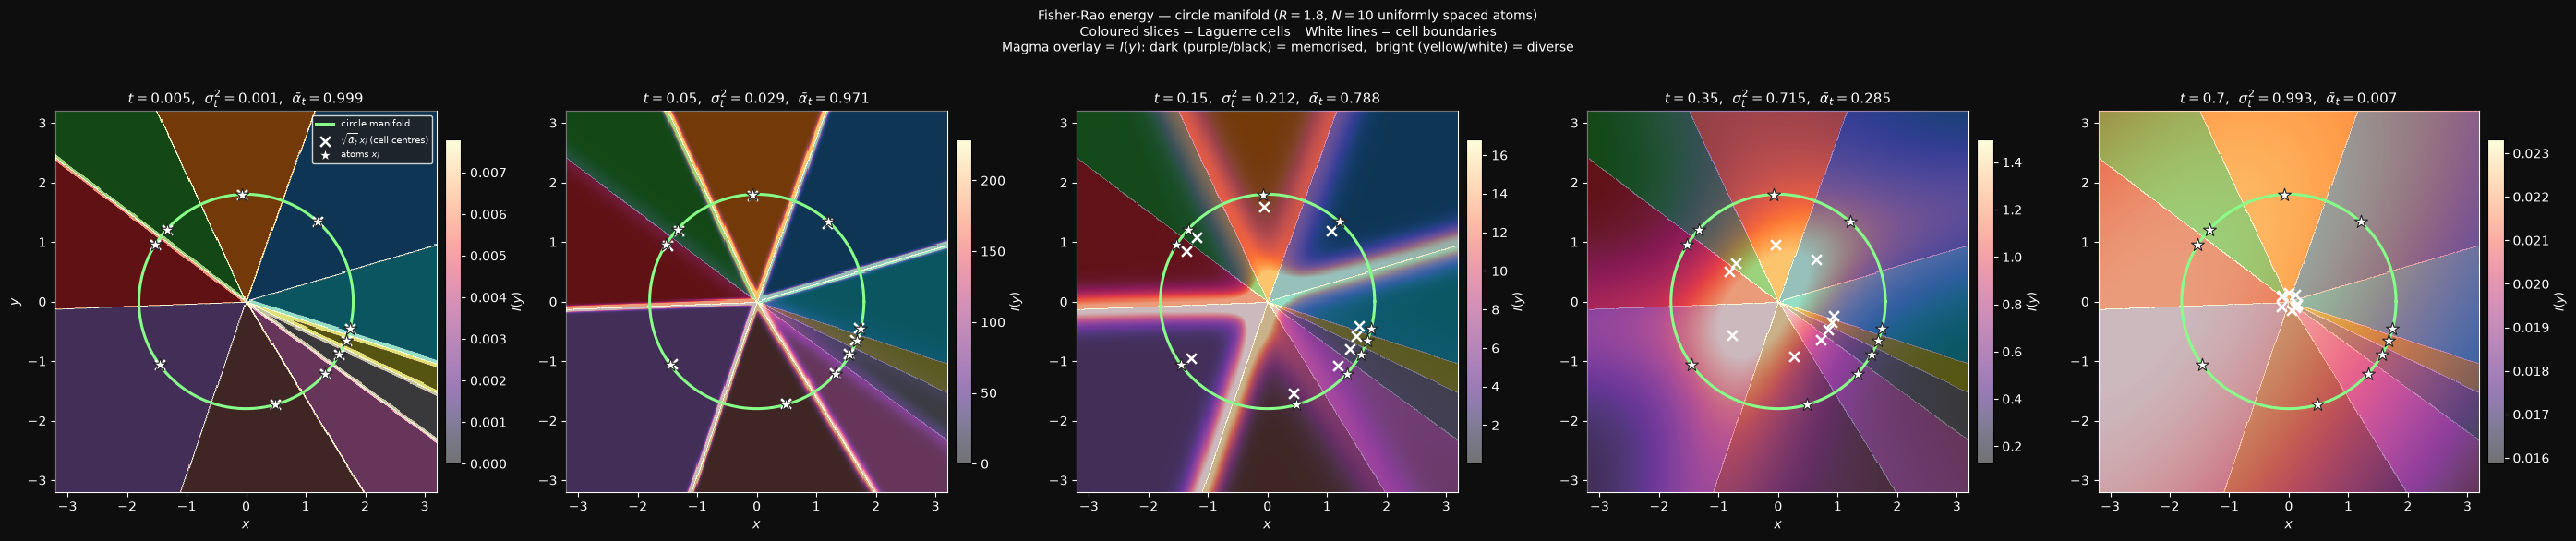

In [17]:
qual_colors_c = [plt.colormaps['tab10'](i / N_CIRCLE) for i in range(N_CIRCLE)]
cell_cmap_c   = ListedColormap(qual_colors_c)

fig, axes = plt.subplots(1, len(T_CIRCLE), figsize=(5.6 * len(T_CIRCLE), 5.6),
                          facecolor='#0e0e0e')

for ax, t_val in zip(axes, T_CIRCLE):
    ax.set_facecolor('#0e0e0e')
    gx, gy, GX, GY, energy, assignment, ab, s2 = compute_grid_circle(t_val)
    mu_np = (X_circle * ab**0.5).numpy()

    # 1. Laguerre cells (pizza slices)
    ax.pcolormesh(GX, GY, assignment,
                  cmap=cell_cmap_c, vmin=0, vmax=N_CIRCLE - 1,
                  alpha=1.0, shading='auto', zorder=0)

    # 2. Cell boundaries
    h_edge = (assignment[:-1, :] != assignment[1:, :])
    v_edge = (assignment[:, :-1] != assignment[:, 1:])
    hy, hx_idx = np.where(h_edge);  vy, vx_idx = np.where(v_edge)
    if len(hy):
        ax.scatter(gx[hx_idx], (gy[hy] + gy[hy+1]) / 2,
                   s=0.5, color='white', linewidths=0, zorder=2, alpha=0.9)
    if len(vy):
        ax.scatter((gx[vx_idx] + gx[vx_idx+1]) / 2, gy[vy],
                   s=0.5, color='white', linewidths=0, zorder=2, alpha=0.9)

    # 3. Fisher-Rao energy overlay
    e_plot = np.clip(energy, 0, np.percentile(energy, 96))
    im = ax.pcolormesh(GX, GY, e_plot,
                       cmap='magma', alpha=0.55, shading='auto', zorder=3)
    cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cb.set_label(r'$I(y)$', color='white', fontsize=9)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

    # 4. Manifold circle
    ax.plot(curve_c[:, 0].numpy(), curve_c[:, 1].numpy(),
            color='#88ff88', lw=2.2, zorder=5, label='circle manifold')

    # 5. Scaled atom positions (cell centres at time t)
    ax.scatter(mu_np[:, 0], mu_np[:, 1],
               s=60, marker='x', color='white', linewidths=1.8,
               zorder=6, label=r'$\sqrt{\bar{\alpha}_t}\,x_i$ (cell centres)')

    # 6. Original atoms
    ax.scatter(X_circle[:, 0].numpy(), X_circle[:, 1].numpy(),
               s=110, marker='*', color='white',
               edgecolors='#222', linewidths=0.8, zorder=7, label='atoms $x_i$')

    ax.set_xlim(gx[0], gx[-1]);  ax.set_ylim(gy[0], gy[-1])
    ax.set_aspect('equal')
    ax.set_title(f'$t = {t_val}$,  $\\sigma_t^2 = {s2:.3f}$,  $\\bar{{\\alpha}}_t = {ab:.3f}$',
                 fontsize=11, color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('white')
    ax.set_xlabel('$x$', color='white')
    if ax is axes[0]:
        ax.set_ylabel('$y$', color='white')
        ax.legend(fontsize=7, loc='upper right',
                  facecolor='#222', edgecolor='white', labelcolor='white')

fig.suptitle(
    f'Fisher-Rao energy — circle manifold ($R={CIRCLE_R}$, $N={N_CIRCLE}$ uniformly spaced atoms)\n'
    'Coloured slices = Laguerre cells    White lines = cell boundaries\n'
    r'Magma overlay = $I(y)$: dark (purple/black) = memorised,  bright (yellow/white) = diverse',
    fontsize=10, color='white', y=1.01)

plt.tight_layout()
plt.savefig('fisher_rao_circle.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print('Saved → fisher_rao_circle.png')
plt.show()
